# Why regression is called regression

This simulation shows **regression toward the mean** in a single-parent lineage.

- Each person has a **latent height** (their true underlying height tendency).
- The child's latent height is positively correlated with the father's latent height.
- The process preserves the same population mean from generation to generation.
- We observe a **realized height** that adds measurement/real-life noise to the latent height.
- Then we regress realized child height on realized parent height.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(7)


In [3]:
# Simulation settings
n_families = 20000
n_generations = 8
mu_height = 170.0          # cm, long-run mean latent height
sigma_latent = 8.0         # latent SD
rho_latent = 0.65          # parent-child latent correlation
sigma_realization = 3.0    # SD of realized noise

# First generation latent heights
latent_prev = rng.normal(mu_height, sigma_latent, n_families)

rows = []
for gen in range(1, n_generations + 1):
    # Latent child height construction:
    # E[child latent] = mu_height, preserving mean across generations.
    eps = rng.normal(0, 1, n_families)
    latent_child = (
        mu_height
        + rho_latent * (latent_prev - mu_height)
        + np.sqrt(1 - rho_latent**2) * sigma_latent * eps
    )

    # Realized (observed) heights include extra noise around latent values
    realized_parent = latent_prev + rng.normal(0, sigma_realization, n_families)
    realized_child = latent_child + rng.normal(0, sigma_realization, n_families)

    rows.append(
        pd.DataFrame(
            {
                "generation": gen,
                "latent_parent": latent_prev,
                "latent_child": latent_child,
                "realized_parent": realized_parent,
                "realized_child": realized_child,
            }
        )
    )

    latent_prev = latent_child

sim = pd.concat(rows, ignore_index=True)
sim.head()


,generation,latent_parent,latent_child,realized_parent,realized_child
0,1,170.009841,176.084909,169.884896,179.855499
1,1,172.389964,168.287078,173.317311,164.660078
2,1,167.806897,167.204237,165.208541,165.790077
3,1,162.875265,166.072792,158.362061,170.070115
4,1,166.362634,168.135989,166.913211,171.968829


In [4]:
# Check that latent means stay close to the same long-run value
mean_by_generation = sim.groupby("generation")[["latent_parent", "latent_child"]].mean()
mean_by_generation


,latent_parent,latent_child
generation,,
1,169.948459,169.909625
2,169.909625,169.935366
3,169.935366,169.990330
4,169.990330,169.988094
5,169.988094,169.968324
6,169.968324,169.997437
7,169.997437,169.997497
8,169.997497,170.038733


In [5]:
# OLS regression of realized child height on realized parent height
x = sim["realized_parent"].to_numpy()
y = sim["realized_child"].to_numpy()

X = np.column_stack([np.ones_like(x), x])
beta = np.linalg.lstsq(X, y, rcond=None)[0]
intercept, slope = beta

print(f"Intercept: {intercept:.3f}")
print(f"Slope:     {slope:.3f}")
print(f"Long-run mean implied by line: {(intercept / (1 - slope)):.3f} cm")


Intercept: 72.886
Slope:     0.571
Long-run mean implied by line: 170.025 cm


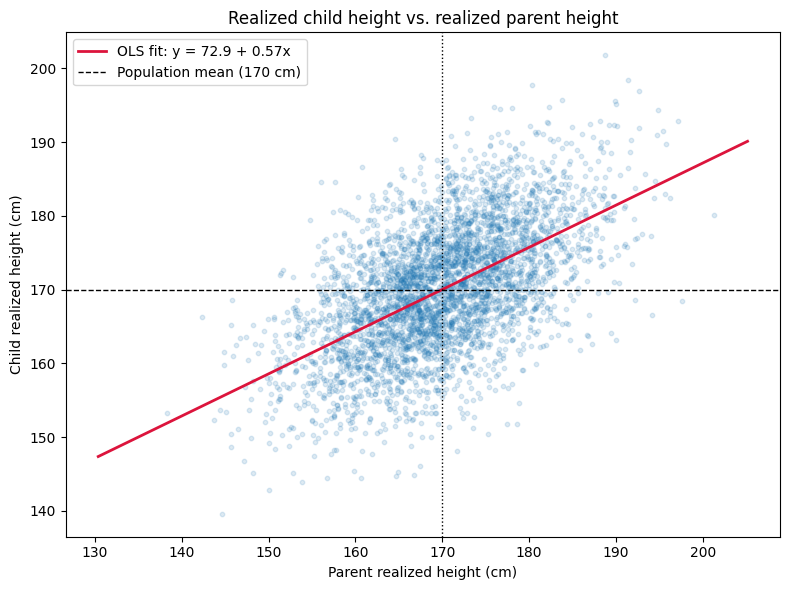

In [6]:
# Visualize parent-child realized heights and fitted line
plt.figure(figsize=(8, 6))

sample = sim.sample(4000, random_state=1)
plt.scatter(sample["realized_parent"], sample["realized_child"], alpha=0.15, s=10)

x_line = np.linspace(sim["realized_parent"].min(), sim["realized_parent"].max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color="crimson", linewidth=2, label=f"OLS fit: y = {intercept:.1f} + {slope:.2f}x")

plt.axhline(mu_height, color="black", linestyle="--", linewidth=1, label=f"Population mean ({mu_height:.0f} cm)")
plt.axvline(mu_height, color="black", linestyle=":", linewidth=1)

plt.title("Realized child height vs. realized parent height")
plt.xlabel("Parent realized height (cm)")
plt.ylabel("Child realized height (cm)")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

Because the slope is less than 1, very tall or very short parents tend to have children whose realized heights are still related to the parent's height, but **closer to the overall mean**. That is the classic phenomenon of **regression toward the mean**, which is where the term "regression" originally came from.
